# Kirman's Ants

The Kirman ant recruitment model {cite:t}`Kirman1993Ants` is a binary-choice
stochastic model on the unit interval. The fraction $x_t \in (0, 1)$ of ants
at one of two food sources evolves under spontaneous switching at rate
$\rho$ and herding at rate $\mu$. In the large-$N$ continuous limit
{cite:p}`MoranEtAl2020SchroedingerCat`, the dynamics are described by the
Itô SDE:

$$
dx_t = \rho \, (1 - 2 x_t) \, dt + \sqrt{2 \mu \, x_t (1 - x_t)} \, dW_t.
$$

The stationary distribution is analytically known:
$x_\infty \sim \text{Beta}(\rho/\mu, \rho/\mu)$. The ratio $\rho/\mu$
determines the regime — unimodal at $x = 1/2$ for $\rho/\mu > 1$,
bimodal with mass at the boundaries for $\rho/\mu < 1$, and uniform at
$\rho/\mu = 1$.

## Module Contents

As with all `MacroStat` models, KirmansAnts is divided into Variables,
Parameters (fixed constants), Scenarios, and the Behavior (model
initialization and steps).

```{eval-rst}
.. toctree::
    :maxdepth: 2

    Variables <variables.rst>
    Parameters <parameters.rst>
    Equations <equations.rst>
    Scenarios <scenarios.rst>
```

## Implementation in MacroStat

KirmansAnts is the first continuous-time SDE model in the package. Each
`step()` runs `substeps = int(1 / dt) = 10_000` Euler-Maruyama micro-steps
inside a numpy loop with boundary rejection, mirroring the abmstat
reference implementation. The base `forward()` is **not** overridden, so
the standard Scenario, parameter-shock, and `record_state` machinery is
preserved. With `record_inner=True`, every micro-step is written to
`behavior_instance._micro_trajectory` (float32), exposing the full
high-resolution trajectory for downstream analysis.

## Model Dynamics

### Preparatory Steps

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import logging
import sys

import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import beta as beta_dist

from macrostat.models.KirmansAnts import KirmansAnts, ParametersKirmansAnts

plt.style.use("../../macrostat.mplstyle")
importlib.reload(logging)
logging.basicConfig(stream=sys.stdout, level=logging.INFO)

### Three regimes

We run the model for the three named scenarios. `record_inner=True` keeps
the full micro-step trajectory available on the behavior instance after
`simulate()` returns.

In [2]:
params = ParametersKirmansAnts(
    hyperparameters={"timesteps": 100, "record_inner": True}
)
model = KirmansAnts(parameters=params)

regimes = {
    "Bimodal (rho=0.5)": (0, 0.5),
    "Uniform (rho=1.0)": (1, 1.0),
    "Unimodal (rho=2.0)": (2, 2.0),
}

trajectories = {}
for label, (scenario, rho_value) in regimes.items():
    model.simulate(scenario=scenario)
    trajectories[label] = (
        model.behavior_instance._micro_trajectory.copy(),
        rho_value,
    )

### Time series and stationary distribution

Each row shows one regime: the left panel plots the first 40,000 micro-steps
(4 time units of SDE evolution); the right panel plots the histogram of the
full trajectory against the analytical $\text{Beta}(\rho/\mu, \rho/\mu)$
density.

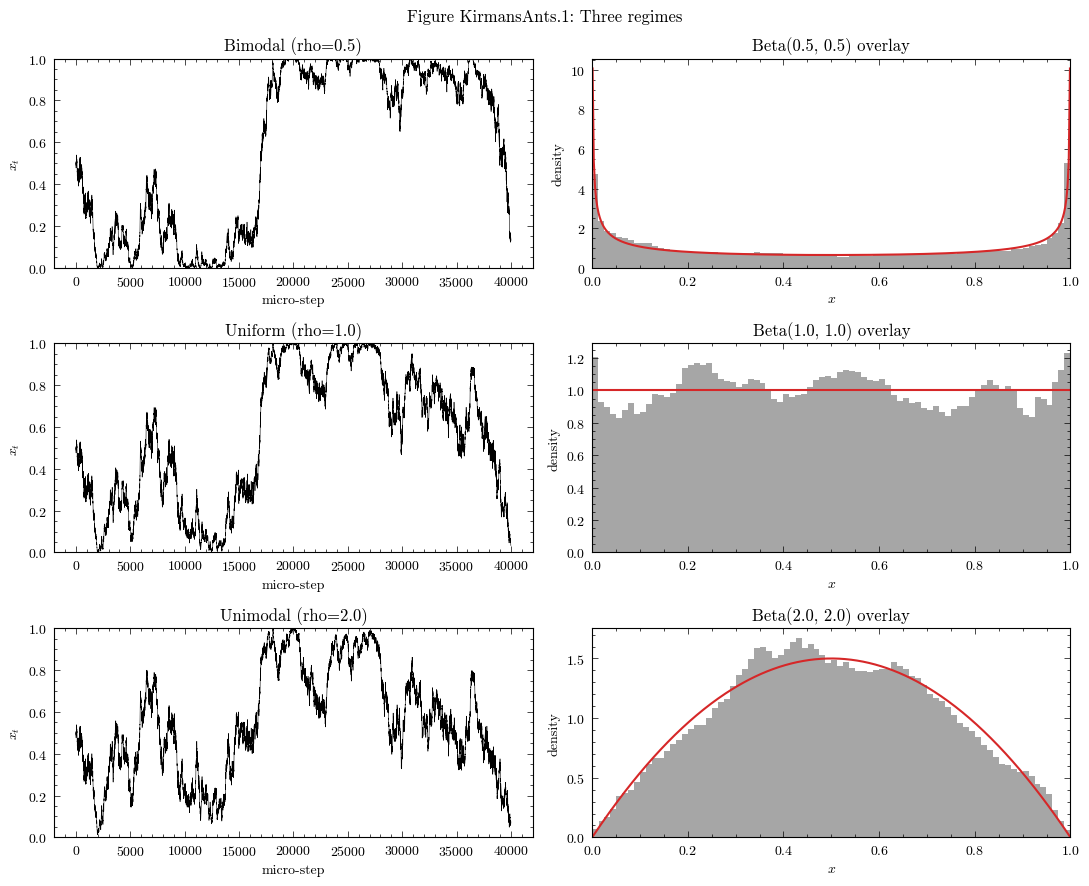

In [3]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(11, 9))

x_grid = np.linspace(1e-3, 1.0 - 1e-3, 400)

for row, (label, (trajectory, rho_value)) in enumerate(trajectories.items()):
    axs[row, 0].plot(trajectory[:40_000], color="k", linewidth=0.4)
    axs[row, 0].set_ylim(0.0, 1.0)
    axs[row, 0].set_title(label)
    axs[row, 0].set_xlabel("micro-step")
    axs[row, 0].set_ylabel(r"$x_t$")

    axs[row, 1].hist(
        trajectory, bins=80, density=True, color="grey", alpha=0.7
    )
    pdf = beta_dist.pdf(x_grid, rho_value, rho_value)
    axs[row, 1].plot(x_grid, pdf, color="tab:red", linewidth=1.5)
    axs[row, 1].set_xlim(0.0, 1.0)
    axs[row, 1].set_xlabel(r"$x$")
    axs[row, 1].set_ylabel("density")
    axs[row, 1].set_title(rf"Beta({rho_value}, {rho_value}) overlay")

fig.suptitle("Figure KirmansAnts.1: Three regimes")
plt.tight_layout()
plt.show()

### Notes

- `model.variables.timeseries["density"]` carries one end-of-time-unit
  value per outer step; the full micro-step trajectory is on the behavior
  instance.
- The model is non-differentiable;
  `BehaviorKirmansAnts.supports_differentiable = False` so passing
  `differentiable=True` raises `RuntimeError` at construction.